# 02 - mRMR Selection Metrics

Creates three outputs:

1. MIQ score vs RMSE/Kendall scatter (binary)
2. 2x2 objective bar chart
3. 2x4 selection-step metric panels

In [5]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mrmr").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing mrmr/")


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "mrmr" / "viz" / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import nb_utils as _nb_utils

_nb_utils = importlib.reload(_nb_utils)

BINARY_DATASETS_DEFAULT = _nb_utils.BINARY_DATASETS_DEFAULT
build_mrmr_methods = _nb_utils.build_mrmr_methods
run_notebook_02 = _nb_utils.run_notebook_02


SETTING = ("binned_interpolation", "5%", "30")

# One entry per line for easy commenting/uncommenting.
BINARY_DATASETS = [
    "ifeval",
    "openllm_math",
    "mmlu_pro",
    "arc_challenge",
    "bbh",
    "gpqa",
    "musr",
    "commonsense",
    "gsm",
    "legalbench",
    "math",
    "med_qa",
    "mmlu",
]

# Toggle this for ifeval-only objective bars.
IFEVAL_ONLY = False

BINARY_DATASETS = BINARY_DATASETS or BINARY_DATASETS_DEFAULT

# -------------------------------
# Method controls
# -------------------------------
MAIN_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    "lasso",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    # "small_search_and_learn",
    # "ksmall_search_and_learn",
    "kanchor_points_predictor",
    "anchor_points_weighted",
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    # "pirt1",
    "gpirt1",
    # "pirt1+",
    "gpirt1+",
    # "kpirt1+",
    "kgpirt1+",
    "metabench",
]

MRMR_MAIN = [(m, m.replace("5_", "_")) for m in build_mrmr_methods(degrees=[1, 2], mi_ks=[5], objectives=["MIQ"], targets=["y"])]
MAIN_METHODS = [*MAIN_METHODS, *MRMR_MAIN]

OBJECTIVE_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    # "random_sampling_and_learn",
    # "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    "lasso",
    "anchor_points_weighted",
    "metabench",
    ("gpirt1", "gpirt"),
    ("gpirt5", "gpirt"),
    ("gpirt10", "gpirt5", "gpirt"),
    ("mrmr3_MIQ_y", "mrmr_MIQ_y"),
    ("mrmr5_MIQ_y", "mrmr5_MIQ_y"),
    ("mrmr7_MIQ_y", "mrmr7_MIQ_y"),
    ("mrmr3_MID_y", "mrmr_MID_y"),
    ("mrmr5_MID_y", "mrmr5_MID_y"),
    ("mrmr7_MID_y", "mrmr7_MID_y"),
    # ("kmrmr3_MIQ_y", "kmrmr_MIQ_y"),
    # ("kmrmr5_MIQ_y", "kmrmr5_MIQ_y", "kmrmr_MIQ_y"),
    # ("kmrmr7_MIQ_y", "kmrmr7_MIQ_y"),
]

SELECTION_METHODS: list[str | tuple[str, ...]] = [
    ("mrmr3_MIQ_y", "mrmr_MIQ_y"),
    ("mrmr5_MIQ_y", "mrmr5_MIQ_y"),
    ("mrmr7_MIQ_y", "mrmr7_MIQ_y"),
    ("mrmr_FCQ_y", "mrmr_FCQ_y"),
    ("mrmr3_MID_y", "mrmr_MID_y"),
    ("mrmr5_MID_y", "mrmr5_MID_y"),
    ("mrmr7_MID_y", "mrmr7_MID_y"),
    ("mrmr_FCD_y", "mrmr_FCD_y"),
]

/home/dg22309/Documents/mrmr_project/mrmr/viz/notebooks/nb_utils.py:3186: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/02_mrmr_selection_metrics/miq_score_vs_rmse_tau_binary.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/02_mrmr_selection_metrics/selection_objective_bars_2x2.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/02_mrmr_selection_metrics/selection_metrics_steps_2x4.pdf')]
miq_score_vs_rmse_tau_binary.pdf


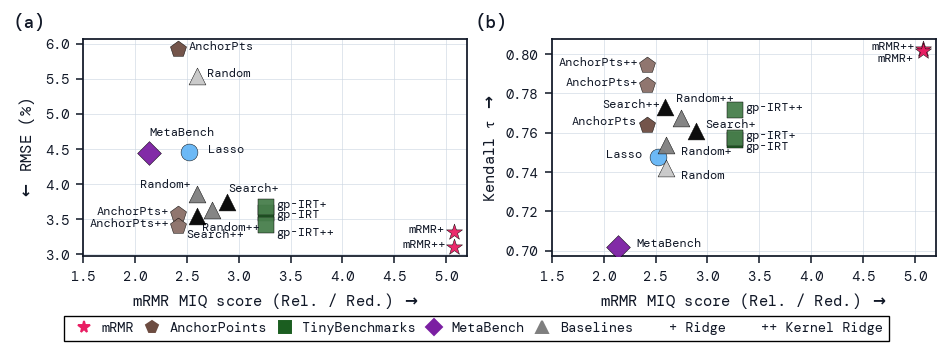

selection_objective_bars_2x2.pdf


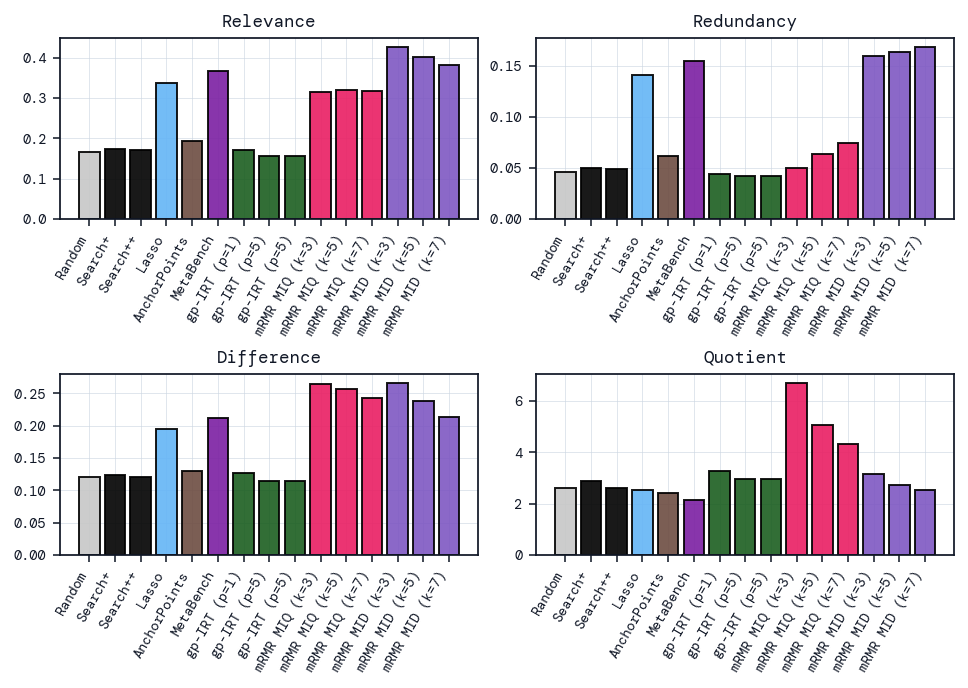

selection_metrics_steps_2x4.pdf


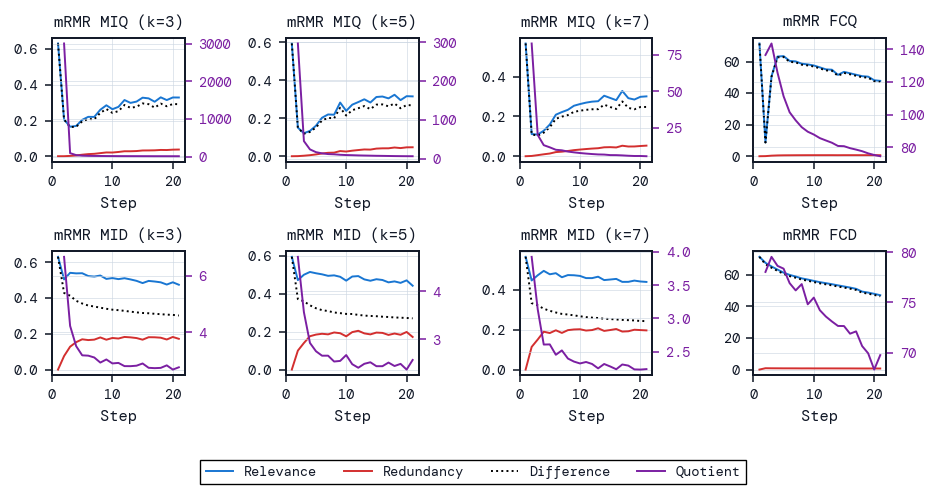

In [6]:
outputs, figures = run_notebook_02(
    setting=SETTING,
    datasets_binary=BINARY_DATASETS,
    ifeval_only=IFEVAL_ONLY,
    main_methods=MAIN_METHODS,
    objective_methods=OBJECTIVE_METHODS,
    selection_methods=SELECTION_METHODS,
    save_outputs=True,
    show_saved_plots=False,
    return_figures=True,
    close_figures=False,
)

print(outputs)
import matplotlib.pyplot as plt
for key, fig in figures.items():
    print(key)
    display(fig)
    plt.close(fig)